# Model Explainability using SHAP

## Objective

High predictive performance alone is insufficient for trustworthy machine learning systems.

This notebook investigates model interpretability using SHAP (SHapley Additive exPlanations) to identify which textual features contribute most strongly to fake news predictions.

Research Questions:

- Which words are most influential for fake news classification?
- Which words are most influential for real news classification?
- Are the learned patterns intuitive and interpretable?

In [ ]:
!pip install shap -q

## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np

import shap

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC

import matplotlib.pyplot as plt

## Loading Dataset

The cleaned dataset generated in Notebook 1 is used for explainability analysis.

In [ ]:
df = pd.read_csv("clean_news.csv")

df["content"] = df["title"] + " " + df["text"]

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["content"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

## TF-IDF Feature Construction

Explainability is performed using the Linear SVM baseline because SHAP analysis is significantly more efficient on sparse TF-IDF features than on transformer architectures.

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

## Training Linear SVM

In [ ]:
svm = LinearSVC()

svm.fit(
    X_train_tfidf,
    y_train
)

LinearSVC()

## Preparing Data for SHAP

In [ ]:
feature_names = vectorizer.get_feature_names_out()

X_sample = X_test_tfidf[:500]

## Computing SHAP Values

SHAP values estimate the contribution of each feature toward the model's prediction.

In [ ]:
explainer = shap.LinearExplainer(
    svm,
    X_train_tfidf
)

In [ ]:
shap_values = explainer.shap_values(
    X_sample
)

## Global Feature Importance

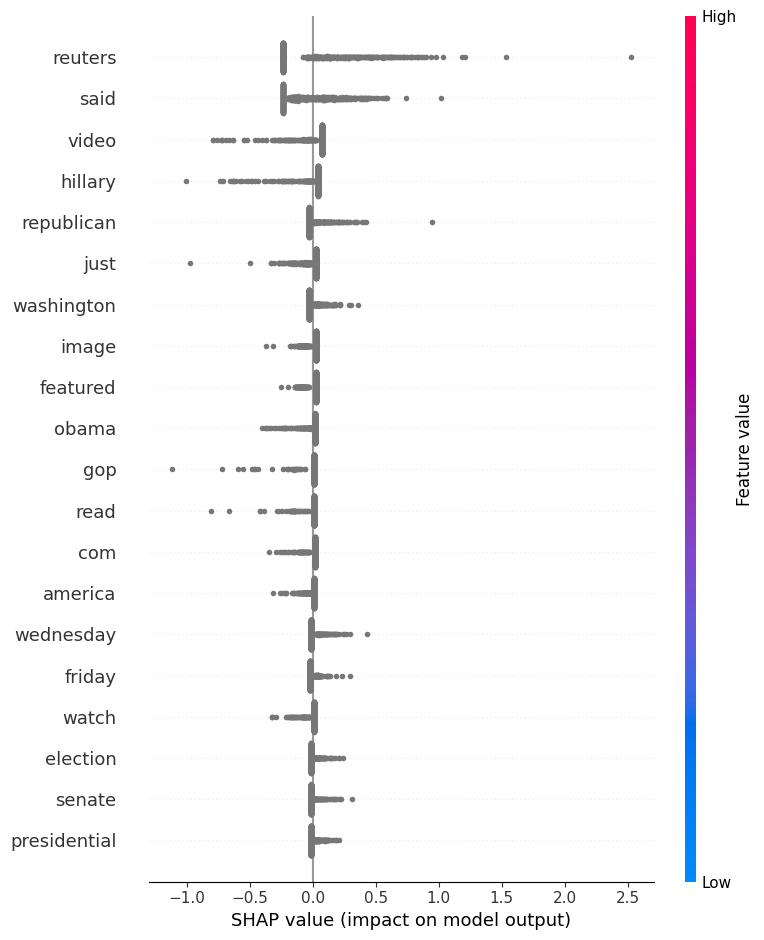

In [ ]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

## Top Influential Words

In [ ]:
importance = np.abs(
    shap_values
).mean(axis=0)

top_idx = np.argsort(
    importance
)[-20:]

In [ ]:
top_words = pd.DataFrame({
    "Word": feature_names[top_idx],
    "Importance": importance[top_idx]
})

top_words.sort_values(
    "Importance",
    ascending=False
)

,Word,Importance
19,reuters,0.274778
18,said,0.175607
17,video,0.098710
16,hillary,0.072540
15,republican,0.051744
14,just,0.049088
13,washington,0.041565
12,image,0.038882
11,featured,0.035585
10,obama,0.032927


## Visualizing Top Words

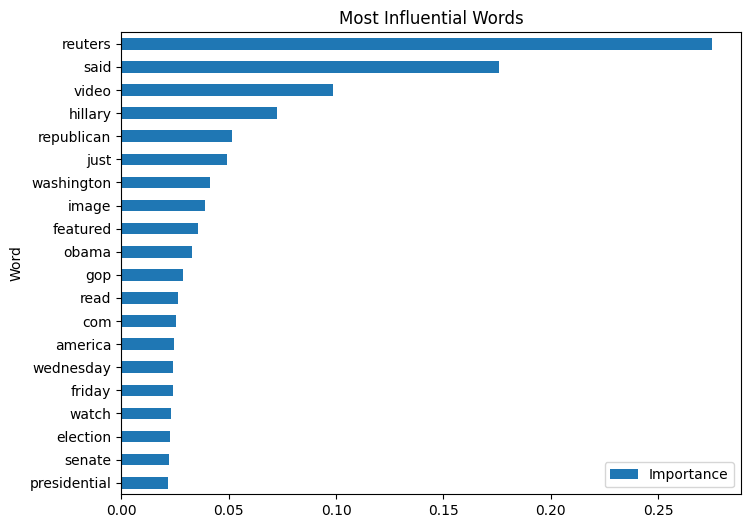

In [ ]:
top_words.sort_values(
    "Importance"
).plot(
    x="Word",
    y="Importance",
    kind="barh",
    figsize=(8,6)
)

plt.title(
    "Most Influential Words"
)

plt.show()

## Local Explanation

SHAP can also explain individual predictions.

The following example illustrates which words contributed most strongly to a specific article classification.

In [ ]:
sample_idx = 0

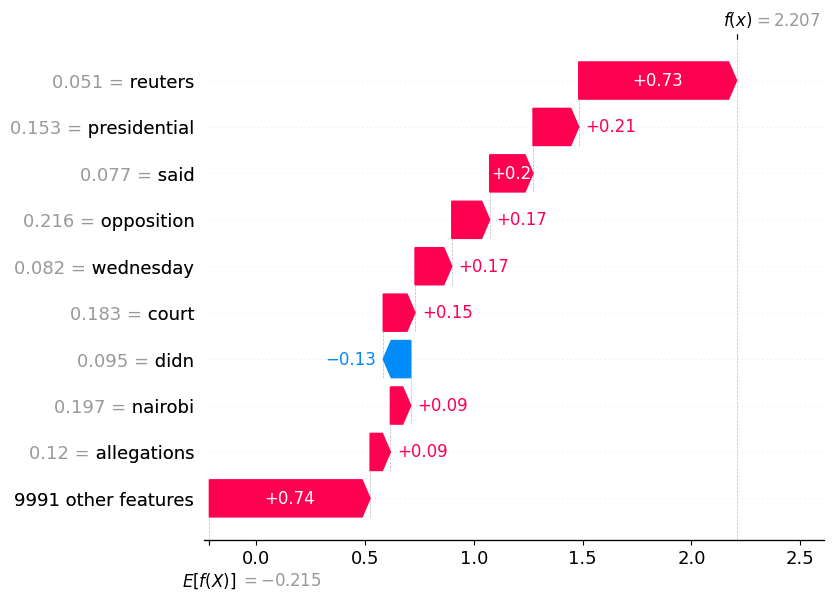

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_sample[sample_idx].toarray()[0],
        feature_names=feature_names
    )
)

## Discussion

The SHAP analysis reveals the vocabulary most strongly associated with fake and real news classifications.

Words receiving consistently large SHAP values contribute heavily to the model's decision-making process and provide insight into the linguistic signals used during classification.

This analysis improves model transparency and helps validate that predictions are driven by meaningful textual patterns rather than dataset artifacts.

# Conclusions

## Key Findings

- SHAP successfully identified influential textual features.
- The Linear SVM model relied on a small subset of highly discriminative words and phrases.
- Explainability analysis improved transparency and interpretability of model predictions.

## Research Takeaway

Understanding why a model makes predictions is as important as achieving high predictive performance.

The SHAP framework provides a principled mechanism for interpreting fake news detection systems and validating that learned patterns are meaningful.

## Next Step

Notebook 05 will investigate robustness and error analysis using the misclassified articles identified during transformer evaluation.